In [ ]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot
# from useful_stuff.general_utils.RSA import  dRSA
# from useful_stuff.general_utils.II import  dRSA, dynInformationImbalance
from useful_stuff.general_utils.regression import  dyn_linear_encoding
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_meg_data, load_eyetracking_data
from project_specific_utils.utils import subsampling_lagged_comparisons, subsampling_RSA, subsampling_II, subsampling_encoding 
from image_processing.gaze_dep_models import save_ANN_features


In [20]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    gaze_fs = 50
    mod_fs = 23.976
    sq_side = 384
    sensors_group = 'occ'
    model_name = "vit_l_16"
    full_model_name = "alexnet_features.4"
    time_points = 600
    pseudotrials_n = 50
    max_lag = 200
    iterations_n = 100
    repetition = 0
    RDM_metric = "correlation"
    pkg = 'timm'
    regr_out_eyes = 'PCR' # or None or pointwise
    
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)

In [3]:
def plot_rsa(tot_rsa, neu_fs, max_lag, title=None, tick_step=20):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # --- heatmap ---
    ax[0].imshow(tot_rsa)

    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / neu_fs, 2)
    ticks += max_lag

    # --- lag plot ---
    lagplot = get_lagplot(tot_rsa, max_lag=max_lag)
    ax[1].plot(lagplot)

    ax[1].set_ylabel("dRSA similarity")
    ax[1].set_xlabel("lag [sec]")
    ax[1].set_xticks(ticks, ticks_labels)
    ax[1].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)

    # --- 🔥 compute peak ---
    peak_idx = np.argmax(lagplot)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / neu_fs  # convert to seconds

    # --- 🔥 textbox ---
    textstr = f"magnitude: {peak_val:.3f}\nlag: {peak_lag:.2f}s"
    ax[1].text(
        0.05, 0.95, textstr,
        transform=ax[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    # --- labels ---
    ax[0].set_xlabel(f"Model time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_ylabel(f"Neural time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()



In [5]:
mod = []
len_mod = []
for i_run in range(1,4):
    model_filename = save_ANN_features(paths, cfg.full_model_name, cfg.mod_fs, cfg.sub_num, i_run + 3*cfg.repetition, 1000, cfg.sq_side, 'all')
    with h5py.File(model_filename, "r") as f:
        run_mod = f['vecrep'][:]
    # end with h5py.File(model_filename, "r") as f:
    run_mod = TimeSeries(run_mod, cfg.mod_fs)
    run_mod.resample(cfg.neu_fs)
    len_mod.append(len(run_mod)) 
    mod.append(run_mod.get_array())
# end for i_run in range(1,4):
mod = TimeSeries(np.concatenate(mod, axis=1), cfg.neu_fs)


In [ ]:
def load_concat_regressout_meg(paths, sub_num, repetition, sensors_group, neu_fs, gaze_fs, regress_out_eyes, PCs_to_keep):
    neu = []
    gaze = []
    print(f"Regressing out eyes: {regress_out_eyes}")
    # TODO create a function to preprocess stuff
    # TODO len_mod is a list with three numbers... consider adding a constant to the project_specific_utils (but first check that it is the same across subjects and runs, otherwise load always e.g. the pixelwise luminance)
    # TODO crop the part between the 1st and second trial
    # TODO thi of returning also gaze so that you don't have to load it every time you load a model
    runs = np.arange(1,4)+3*cfg.repetition 
    for idx, i_run in enumerate(runs):
        run_neu, labels = load_meg_data(paths, sub_num, i_run + 3*repetition, sensors_group, neu_fs)
        run_neu.z_score_feats()
        run_gaze, _ = load_eyetracking_data(paths, sub_num, i_run + 3*repetition, gaze_fs, xy=True)
        run_neu = TimeSeries(run_neu[:len_mod[idx]], run_neu.get_fs())
        if cfg.regr_out_eyes == "PCR":
            run_gaze.z_score_feats()
            run_gaze.resample(cfg.neu_fs)
            run_gaze = TimeSeries(run_gaze[:len_mod[idx]], run_gaze.get_fs())
            dyn_regr_obj = dyn_linear_encoding('lr', 'same', None)
            if cfg.regr_out_eyes == "PCR":
                y_regress_out, _ = dyn_regr_obj.delay_embed_PCR_regress_out(run_gaze, run_neu, (-100, 100), PCs_to_keep=PCs_to_keep, pad_mode='edge', crop_end=True)
            elif cfg.regr_out_eyes == "lag0":
                y_regress_out = dyn_regr_obj.pointwise_regress_out(run_gaze,run_neu, regression_type=None) 
            # end if cfg.regr_out_eyes == "PCR":
            neu.append(y_regress_out[:len_mod[idx]])
        # end if cfg.regr_out_eyes:
    # end for i_run in range(1,4):
    neu = TimeSeries(np.concatenate(neu, axis=1), cfg.neu_fs)
    return neu
# EOF

def load_concat_regressout_mod():
    pass

Regressing out eyes: True


In [ ]:
neu = []
print(f"Regressing out eyes: {cfg.regr_out_eyes}")
# TODO create a function to preprocess stuff
runs = np.arange(1,4)+3*cfg.repetition 
for i_run in runs:
    run_neu, labels = load_meg_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.sensors_group, cfg.neu_fs)
    run_neu.z_score_feats()
    # run_neu, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
    # run_neu.resample(cfg.neu_fs)
    if cfg.regr_out_eyes:
        run_gaze, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
        run_gaze.z_score_feats()
        run_gaze.resample(cfg.neu_fs)
        min_len = min(len(run_gaze), len(run_neu))
        run_gaze = TimeSeries(run_gaze[:min_len], run_gaze.get_fs())
        run_neu = TimeSeries(run_neu[:min_len], run_neu.get_fs())
        dyn_regr_obj = dyn_linear_encoding('lr', 'same', None)
        # y_regress_out = dyn_regr_obj.pointwise_regress_out(run_gaze,run_neu, regression_type=None) 
        y_regress_out, _ = dyn_regr_obj.delay_embed_PCR_regress_out(run_gaze, run_neu, (-100, 100), PCs_to_keep=50, pad_mode='edge', crop_end=True)
        neu.append(y_regress_out[:len_mod[i_run-1]])
    else: 
        neu.append(run_neu[:len_mod[i_run-1]])
    # end if cfg.regr_out_eyes:
# end for i_run in range(1,4):
neu = TimeSeries(np.concatenate(neu, axis=1), cfg.neu_fs)

Regressing out eyes: True


In [7]:
# get_spaced_pseudotrials(list(range(0,1000)), 71, 8, 5, discontinuities=list(range(0,1000, 200)), fail_safety=False)

In [9]:
tot_rsa, _ = subsampling_lagged_comparisons(neu, mod, cfg.time_points, cfg.iterations_n - 50, cfg.pseudotrials_n, len_mod, subsampling_RSA, 0, *(cfg.RDM_metric, cfg.RDM_metric),)

19:28:56 - rank 0 starting iteration 0 of 49
19:29:01 - rank 0 starting iteration 10 of 49
19:29:05 - rank 0 starting iteration 20 of 49
19:29:10 - rank 0 starting iteration 30 of 49
19:29:14 - rank 0 starting iteration 40 of 49


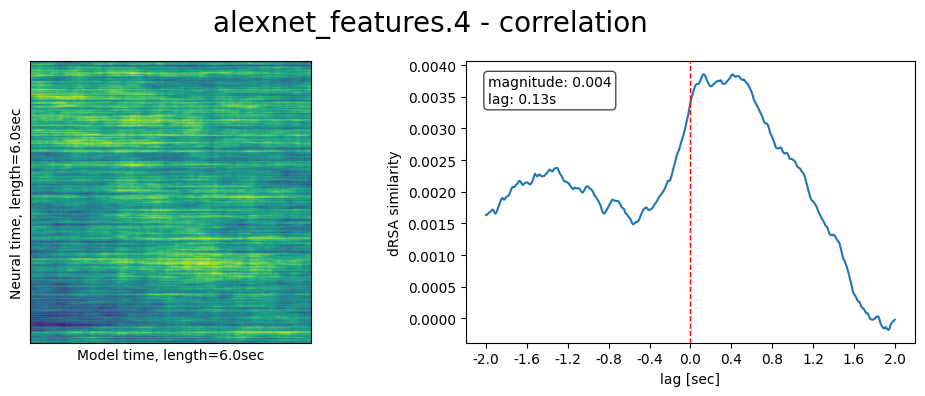

In [10]:
plot_rsa(tot_rsa, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)

In [14]:
tot_II_A2B, tot_II_B2A = subsampling_lagged_comparisons(neu, mod, cfg.time_points, cfg.iterations_n-80, cfg.pseudotrials_n, len_mod, subsampling_II, 0, *(cfg.RDM_metric, cfg.RDM_metric),**{"k": 20})

19:32:48 - rank 0 starting iteration 0 of 19
19:33:32 - rank 0 starting iteration 10 of 19


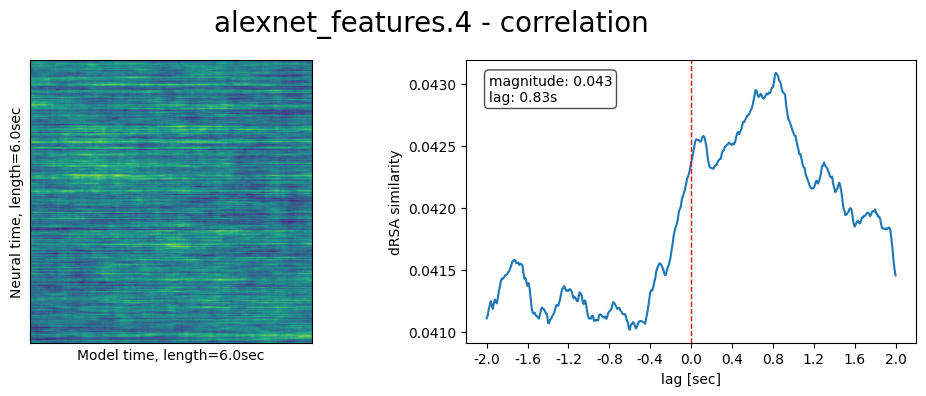

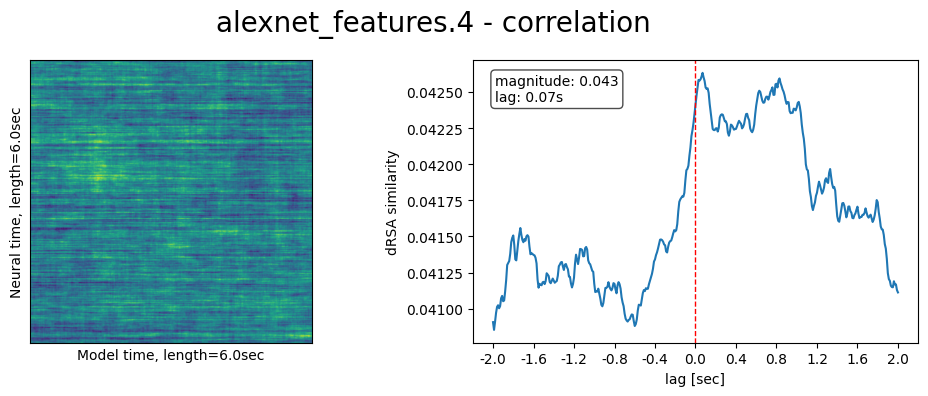

In [15]:
plot_rsa(1-tot_II_A2B, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)
plot_rsa(1-tot_II_B2A, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40) #TODO check if the dynII is correct in its timecourse...

In [27]:
print(cfg.pseudotrials_n)

50


In [ ]:
r = subsampling_lagged_comparisons('encoding', neu, mod, cfg.time_points, cfg.iterations_n - 99, cfg.pseudotrials_n, subsampling_encoding, 0, *('ridge', 'kf', 5),**{"score_type": "corr", "n_splits": 2, }) 

12:40:25 - rank 0 starting iteration 0 of 0
(1, 11)


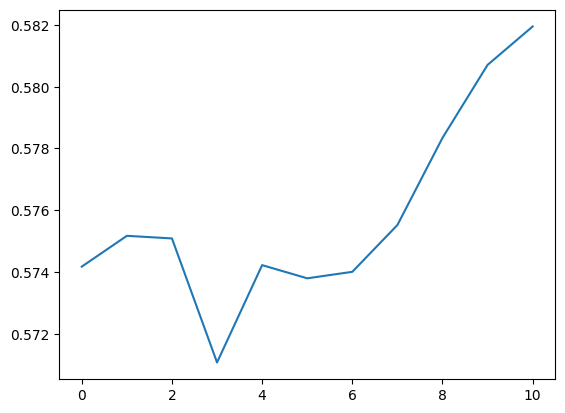

In [47]:
plt.plot(r.T);